### BERT(Bidirectional Encoder Representations from Transformer)
- "트랜스포머 기반의 양방향 인코더가 만들어내는 표현" <br>
BERT는 Transformer의 인코더만 가져다가 대규모 텍스트로 사전학습(Pre-training)한 모델<br>
**핵심**
- Bidirectional: 문장을 양방향 동시에 읽음
- Encoder: Transformer의 Encoder 부분만 사용
- Pre-training: 특정 태스크용으로 만든 것이 아닌, 범용적인 언어 이해 능력을 먼저 학습

#### 1. 왜 인코더만 사용할까? -GPT와 결정적 차이
Transformer = Encoder + Decoder 구조
- Encoder: 문장 전체를 한꺼번에 읽고 이해하는 데 특화 -> BERT
- Decoder: 이전 단어들을 보고 다음 단어를 생성하는 데 특화 -> GPT

##### BERT의 목표
- 문장의 의미를 깊이 이해하는 표현을 만드는 것
번역이나 문장 생성이 아닌 분류, 질의응답, 감성 분석과 같은 이해 Task를 잘하기 위해서는 **문장 전체를 양방향으로 동시에(모든 단어가 모든 단어를 동시에 참조)** 볼 수 있어야 함

#### 2. BERT의 입력 구조
##### (1) BERT에 입력을 넣기 전 세 가지 특수 처리 진행
ex) [CLS] 나는 학교에 간다 [SEP] 오늘 날씨가 좋다 [SEP]
- [CLS]: 문장 맨 앞에 항상 붙는 토큰으로, 이 토큰의 최종 출력 벡터가 문장 전체의 표현으로 사용됨
- [SEP]: 두 문장을 구분하는 구분자 토큰

##### (2) 세 가지 임베딩의 합산
$$ 최종 입력 = Token Embedding + Segment Embedding + Position Embedding $$
- Token Embedding: 각 단어의 의미 벡터
- Segment Embedding: 첫 번째 문장인지 두 번째 문장인지 표시
- Position Embedding: Positional Encoding과 동일한 역할(BERT는 $\sin / \cos$ 대신 학습되는 위치 임베딩 사용)

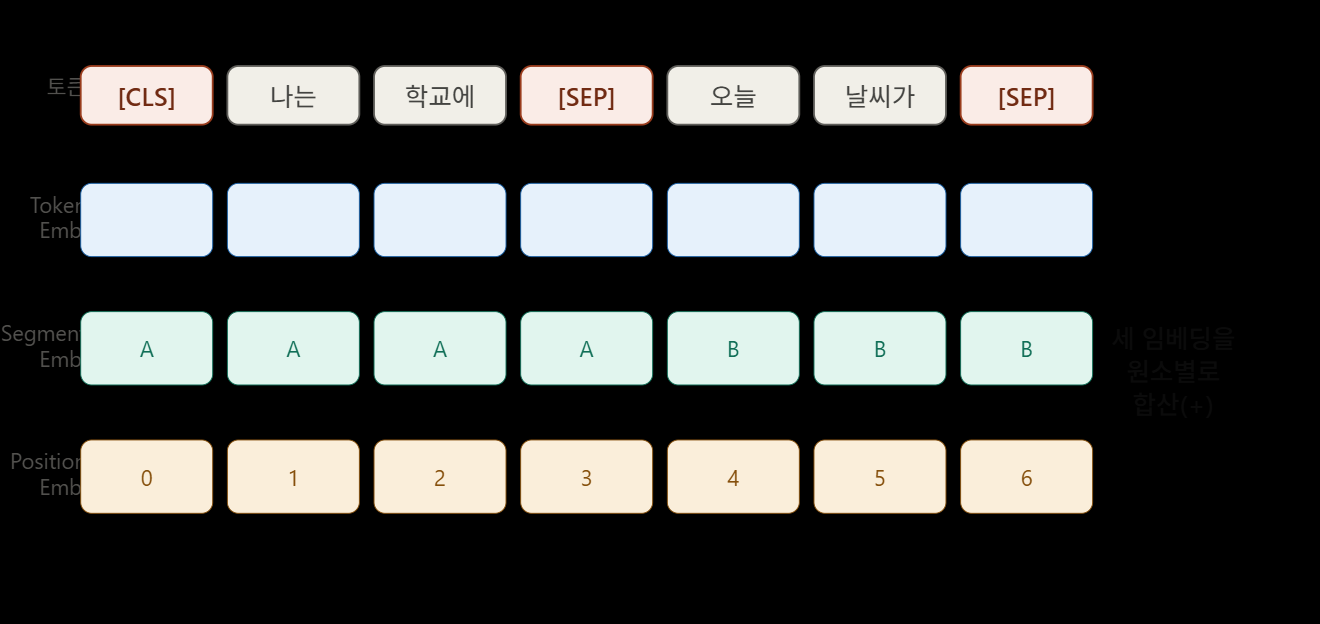

Q1. 임베딩을 더하면 각 임베딩이 지닌 정보가 희석되는 것 아닌가?
A1. 
- 고차원 공간에서는 무작위로 뽑은 두 벡터는 **"거의 직교에 가까움"**
- "학습되는 파라미터"라는 점
    : Token, Segment, Position Embedding 모두 학습되는 값. 학습 과정에서:
    - Token Embedding: 더한 결과에서 내 몫의 신호가 다음 레이어(Attention, FFN)에 잘 전달되도록 값을 조정
    - Segment/Position Embedding: 마찬가지로 자기 몫이 살아남도록 조정
    
    -> 즉, 세 임베딩이 서로 겹쳐도 구분 가능한 방향으로 자리잡도록 역전파가 알아서 최적화


#### 3. BERT의 두 가지 사전학습 태스크
##### (1) MLM(Masked Language Model) - "빈칸 채우기"
- 전체 토큰 중 무작위로 15%를 선택해 처리
    - 선택된 토큰의 80%: [MASK]로 교체
    - 선택된 토큰의 10%: 랜덤한 다른 단어로 교체
    - 선택된 토큰의 10%: 그대로 유지

    -> 80/10/10으로 나눠 "모든 토큰의 표현을 항상 문맥 기반으로 만들도록" 설계
- 원래 단어가 뭐였는지 추론

-> 손실함수: Cross-Entropy Loss 사용(어휘 사전 단어 중 어떤 단어가 정답인지 맞추는 "분류" 문제). Softmax로 확률을 구한 후 정답 단어의 $-\log{(p)}$를 최소화

##### (2) NSP(Next Sentence Prediction) - "이어지는 문장인가?"
두 문장을 이어서 넣고 두 번째 문장이 첫 번째 문장의 실제 다음 문장인지(IsNext) 또는 무작위로 뽑은 문장인지(NotNext)를 맞추도록 함

ex)
[CLS] 나는 학교에 갔다 [SEP] 오늘 수업이 재밌었다 [SEP] -> **IsNext** <br>
[CLS] 나는 학교에 갔다 [SEP] 하늘에는 별이 빛난다 [SEP] -> **NotNext**

[CLS] 토큰의 최종 출력 벡터 하나를 받아 이진 분류(IsNext, NotNext) 수행 <br>
MLM으로 개별 단어 수준의 이해는 가능하지만 두 문장 사이의 관계 학습이 어려움 -> 이를 NSP가 보완

#### 4. 왜 이 두 Task가 "언어 이해"를 가르치는가
MLM와 NSP는 레이블이 별도로 필요하지 않음(인터넷에 있는 텍스트 자체에서 자동으로 만들 수 있음)
- MLM: 원문에서 단어를 가리기만 하면 됨 -> 정답: 원래 단어
- NSP: 실제 연속된 문장 - IsNext, 랜덤으로 뽑은 문장 - NotNext -> 정답이 자동 생성

-> 이를 **자기지도학습(Self-Supervised Training)**이라 함. BERT는 Wikipedia + Bookscorpus로 사전학습 <br>
이 과정에서:
- "학교", "병원", "도서관"은 서로 비슷한 문맥에서 등장 -> 유사한 표현 학습
- "나는", "그는", "그녀는"은 주어 위치에서 유사하게 기능 -> 문법 구조 학습
- "행복했다", "슬펐다"는 감성이 반대 -> 반대 방향 벡터 학습

#### 5. Fine-Tuning
사전학습을 마친 BERT - "언어는 깊이 이해하지만, 특정 Task를 풀지 못하는 상태" <br>
-> Fine-Tuning: 사전학습된 가중치 위에 Task별 레이어를 얹고, 적은 양의 레이블 데이터로 추가 학습하는 과정

##### (1) 학습 방식
Fine-Tuning 시 BERT의 모든 가중치와 함께 업데이트 <br>
-> 사전학습 가중치 고정 X. 단, 학습률은 $10^{-5}$ 수준으로 작게. * 사전학습 가중치는 매우 좋은 시작점이므로 오히려 크게 바꾸면 망가짐(= Catastrophic Forgetting). 적은 학습률로 살짝만 조정해 Task에 특화시켜야 함

##### (2) 구조
- Task 1. 문장 분류: 감성 분석, 주제 분류 등에 사용 <br>
    [CLS] 이 영화는 정말 재밌었다 [SEP] -> [CLS] 출력 -> Linear -> Softmax -> 긍정/부정 <br>
    -> [CLS] 토큰의 최종 출력 벡터에 선형 레이어 하나 추가

- Task 2. 질의응답: "문서에서 질문의 답이 되는 구간을 찾아라" 형태 <br>
    [CLS] 질문 [SEP] 문서 [SEP] <br>
    -> 모델이 예측해야 할 건 답변 구간의 시작/끝 위치 2개로, 각 토큰의 위치마다 답의 시작과 끝을 독립적 분류

- Task 3. 개체명 인식: "각 단어가 장소, 기관명, 사람 이름 등 인가"를 분류
    [CLS] 홍길동은 서울에서 태어났다 [SEP] <br>
    -> 문장 분류와 달리 모든 토큰의 출력 벡터에 각각 분류 레이어를 얹음


### 실습 코드: IMDB 영화 리뷰 감정분류

In [1]:
!pip install transformers datasets -q

In [2]:
!pip uninstall torchvision -y6


Usage:   
  pip3 uninstall [options] <package> ...
  pip3 uninstall [options] -r <requirements file> ...

no such option: -6


device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch 2/3 [Val]:   0%|          | 0/782 [00:00<?, ?it/s]

epoch 2/3 | train_loss=0.1351 | val_loss=0.2317 | val_acc=0.9200


Epoch 3/3 [Train]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/782 [00:00<?, ?it/s]

epoch 3/3 | train_loss=0.0637 | val_loss=0.2604 | val_acc=0.9198


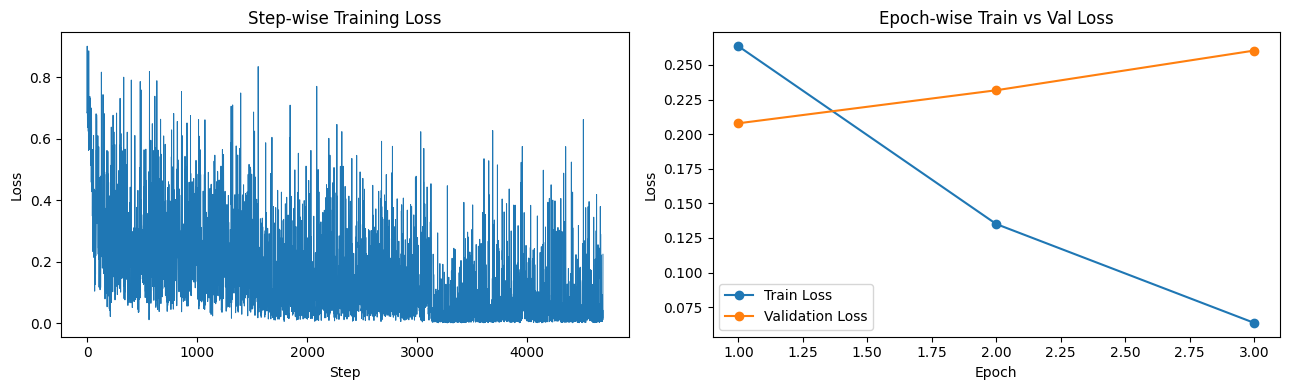

In [5]:
# Colab/VSC 최초 1회:
# !pip install transformers datasets -q

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding
from datasets import load_dataset
from tqdm.auto import tqdm
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)   # GPU 연결 확인용

# ── 1. 실제 데이터: IMDB 전체 (train 25,000 / test 25,000) ──
raw = load_dataset("stanfordnlp/imdb")
train_data = raw["train"].shuffle(seed=42)
test_data  = raw["test"].shuffle(seed=42)

# ── 2. 사전학습된 BERT + 토크나이저 (Day8: 사전학습은 이미 끝난 상태) ──
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name)

def encode(batch):
    # 여기선 max_length로 자르기만 하고, 실제 패딩은 배치 단위로 나중에 (DataCollator가 처리 → 연산 효율)
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_data = train_data.map(encode, batched=True)
test_data  = test_data.map(encode, batched=True)
train_data = train_data.remove_columns(["text"]).rename_column("label", "labels")
test_data  = test_data.remove_columns(["text"]).rename_column("label", "labels")

# train_data.set_format(type="torch")
# test_data.set_format(type="torch")

# 배치마다 그 배치 안에서 가장 긴 문장 길이에 맞춰서만 패딩 (Day8 이론의 패딩 개념 실무 최적화 버전)
collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collator)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=32, collate_fn=collator)

# ── 3. 파인튜닝 모델: 사전학습 BERT + 분류 헤드 ──
class BertClassifier(nn.Module):
    def __init__(self, bert, num_classes=2):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(768, num_classes)   # [CLS] 출력(768) → 클래스 점수 (Day9 이론)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]   # [CLS] 토큰 위치의 출력 (Day8 이론)
        return self.classifier(cls_output)

model = BertClassifier(bert).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)   # 작은 lr → catastrophic forgetting 방지 (Day9)
loss_fn = nn.CrossEntropyLoss()                               # Day4 softmax+CE 재사용

# ── 4. 학습 + loss 기록 ──
step_losses = []        # 매 스텝(배치)마다의 loss → 세밀한 변화 확인용
epoch_train_losses = [] # 에폭별 평균 train loss
epoch_val_losses = []   # 에폭별 평균 validation loss (과적합 여부 확인용)
epoch_val_accs = []

num_epochs = 3
for epoch in range(num_epochs):
    # ---- 학습 ----
    model.train()
    running_loss = 0

    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for batch in train_progress:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()         # BERT 전체 + classifier에 기울기 전파 (Day9: "함께 업데이트")
        optimizer.step()

        step_losses.append(loss.item())
        running_loss += loss.item()
    epoch_train_losses.append(running_loss / len(train_loader))

    # ---- 검증 ----
    model.eval()
    val_loss, correct = 0, 0

    val_progress = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for batch in val_progress:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            val_loss += loss_fn(logits, labels).item()
            correct += (torch.argmax(logits, dim=1) == labels).sum().item()
    epoch_val_losses.append(val_loss / len(test_loader))
    epoch_val_accs.append(correct / len(test_data))

    print(f"epoch {epoch+1}/{num_epochs} | train_loss={epoch_train_losses[-1]:.4f} "
          f"| val_loss={epoch_val_losses[-1]:.4f} | val_acc={epoch_val_accs[-1]:.4f}")

# ── 5. Loss 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (좌) 스텝 단위 loss — 학습 중 세밀한 변화(진동, 수렴 속도)를 확인
axes[0].plot(step_losses, linewidth=0.7)
axes[0].set_title("Step-wise Training Loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")

# (우) 에폭 단위 train vs val loss — 과적합 여부(val loss가 다시 올라가는지) 확인
epochs_x = range(1, num_epochs+1)
axes[1].plot(epochs_x, epoch_train_losses, marker='o', label='Train Loss')
axes[1].plot(epochs_x, epoch_val_losses, marker='o', label='Validation Loss')
axes[1].set_title("Epoch-wise Train vs Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("bert_finetune_loss.png", dpi=150)   # VSC/Colab 어디서든 파일로 저장되어 확인 가능
plt.show()